# Section 1 : Pandas

In [3]:
import pandas as pd

# Section 2 : raw_df

In [4]:
raw_df = pd.read_csv('./data/weatherAUS.csv')

In [5]:
raw_df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


Checking the column types of the dataset.

In [6]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

Droping any rows where the value of the target column RainTomorrow in empty.

In [7]:
raw_df.dropna(subset=['RainTomorrow'], inplace=True)

# Section 3 : Preparing the Data for Training

We'll perform the following steps to prepare the dataset for training:

1. Create a train/test/validation split
2. Identify input and target columns
3. Identify numeric and categorical columns
4. Impute (fill) missing numeric values
5. Scale numeric values to the $(0, 1)$ range
6. Encode categorical columns to one-hot vectors

# Section 3 :  Training, Validation and Test Sets

# Section 3 : matplotlib

In [8]:
import matplotlib.pyplot as plt

# Section 3 : seaborn 

In [9]:
import seaborn as sns

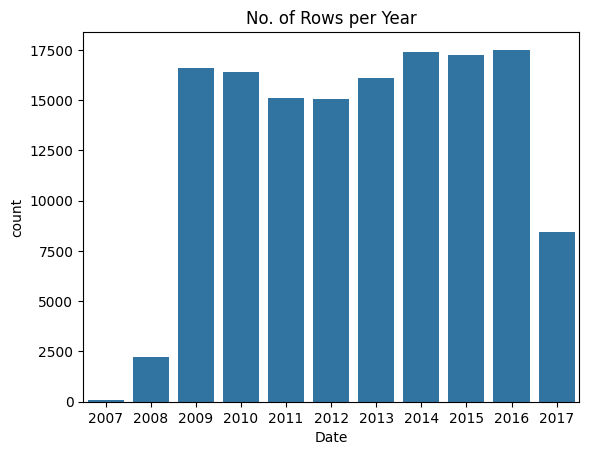

In [10]:
plt.title('No. of Rows per Year')
sns.countplot(x=pd.to_datetime(raw_df.Date).dt.year);

While working with chronological data, it's often a good idea to separate the training, validation and test sets with time, so that the model is trained on data from the past and evaluated on data from the future.

We'll use the data till 2014 for the training set, data from 2015 for the validation set, and the data from 2016 & 2017 for the test set.  

In [11]:
year = pd.to_datetime(raw_df.Date).dt.year

# Section 3 : train_df

In [12]:
train_df = raw_df[year < 2015]

# Section 3 : val_df

In [13]:
val_df = raw_df[year == 2015]

# Section 3 : test_df

In [14]:
test_df = raw_df[year > 2015]

In [15]:
print('train_df.shape :', train_df.shape)
print('val_df.shape :', val_df.shape)
print('test_df.shape :', test_df.shape)

train_df.shape : (98988, 23)
val_df.shape : (17231, 23)
test_df.shape : (25974, 23)


# Section 4 : Input and Target Columns

Let's identify the input and target columns.

# Section 4 : input_cols

In [16]:
input_cols = list(train_df.columns)[1:-1]

In [17]:
input_cols

['Location',
 'MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustDir',
 'WindGustSpeed',
 'WindDir9am',
 'WindDir3pm',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm',
 'RainToday']

# Section 4 : target_col

In [18]:
target_col = 'RainTomorrow'

In [19]:
target_col

'RainTomorrow'

# Section 4 : train_inputs

In [20]:
train_inputs = train_df[input_cols].copy()

In [21]:
train_inputs

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
0,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,...,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No
1,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,...,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No
2,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,...,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No
3,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,...,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No
4,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,...,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144548,Uluru,16.9,33.2,0.0,NaN,NaN,SSE,43.0,ESE,SSE,...,26.0,22.0,13.0,1014.1,1009.8,NaN,NaN,23.7,31.8,No
144549,Uluru,15.1,36.8,0.0,NaN,NaN,NE,31.0,ENE,SW,...,20.0,16.0,8.0,1012.6,1007.6,NaN,NaN,28.9,34.8,No
144550,Uluru,17.3,37.8,0.0,NaN,NaN,ESE,39.0,ESE,SSE,...,9.0,15.0,8.0,1011.9,1008.0,NaN,NaN,29.7,35.7,No
144551,Uluru,20.1,38.5,0.0,NaN,NaN,ESE,43.0,ESE,SSW,...,17.0,22.0,9.0,1014.0,1009.2,NaN,NaN,29.8,37.2,No


# Section 4 : train_targets

In [22]:
train_targets = train_df[target_col].copy()

In [23]:
train_targets

0         No
1         No
2         No
3         No
4         No
          ..
144548    No
144549    No
144550    No
144551    No
144552    No
Name: RainTomorrow, Length: 98988, dtype: object

# Section 4 : val_inputs

In [24]:
val_inputs = val_df[input_cols].copy()

In [25]:
val_inputs

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
2133,Albury,11.4,33.5,0.0,NaN,NaN,WSW,30.0,ESE,W,...,11.0,45.0,14.0,1013.5,1011.0,NaN,NaN,21.0,32.7,No
2134,Albury,15.5,39.6,0.0,NaN,NaN,NE,56.0,ESE,ESE,...,9.0,45.0,12.0,1016.0,1012.4,NaN,NaN,25.6,38.2,No
2135,Albury,17.1,38.3,0.0,NaN,NaN,NNE,48.0,NE,N,...,20.0,35.0,19.0,1017.9,1012.3,NaN,NaN,29.2,37.0,No
2136,Albury,26.0,33.1,0.0,NaN,NaN,NNE,41.0,ESE,W,...,7.0,46.0,37.0,1013.6,1012.1,8.0,5.0,27.4,30.9,No
2137,Albury,19.0,35.2,0.0,NaN,NaN,E,33.0,SSE,SE,...,9.0,60.0,34.0,1017.4,1014.7,8.0,NaN,25.6,32.5,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144913,Uluru,20.5,34.7,0.0,NaN,NaN,E,52.0,ESE,E,...,20.0,23.0,12.0,1013.2,1010.1,NaN,NaN,24.3,33.0,No
144914,Uluru,18.0,36.4,0.0,NaN,NaN,ESE,54.0,E,ESE,...,31.0,17.0,7.0,1014.7,1010.9,NaN,NaN,26.7,35.0,No
144915,Uluru,17.5,37.1,0.0,NaN,NaN,E,56.0,E,SE,...,22.0,12.0,7.0,1012.6,1007.5,NaN,NaN,28.1,34.7,No
144916,Uluru,20.0,38.9,0.0,NaN,NaN,E,59.0,E,SSE,...,17.0,12.0,12.0,1007.2,1002.6,NaN,1.0,31.3,38.4,No


# Section 4 : val_targets

In [26]:
val_targets = val_df[target_col].copy()

In [27]:
val_targets

2133      No
2134      No
2135      No
2136      No
2137      No
          ..
144913    No
144914    No
144915    No
144916    No
144917    No
Name: RainTomorrow, Length: 17231, dtype: object

# Section 4 : test_inputs

In [28]:
test_inputs = test_df[input_cols].copy()

In [29]:
test_inputs

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
2498,Albury,20.4,37.6,0.0,NaN,NaN,ENE,54.0,NaN,ESE,...,7.0,46.0,17.0,1013.4,1009.2,7.0,3.0,26.1,36.7,No
2499,Albury,20.9,33.6,0.4,NaN,NaN,SSE,50.0,SSE,SE,...,17.0,54.0,30.0,1011.1,1008.4,8.0,8.0,24.8,31.7,No
2500,Albury,18.4,23.1,2.2,NaN,NaN,ENE,48.0,ESE,ENE,...,39.0,62.0,67.0,1014.0,1014.8,8.0,8.0,21.8,19.5,Yes
2501,Albury,17.3,23.7,15.6,NaN,NaN,SSE,39.0,SE,SSE,...,17.0,74.0,65.0,1017.9,1016.5,8.0,8.0,19.2,21.6,Yes
2502,Albury,15.5,22.9,6.8,NaN,NaN,ENE,31.0,SE,SSE,...,9.0,92.0,63.0,1016.3,1013.9,8.0,8.0,17.2,22.2,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,Uluru,3.5,21.8,0.0,NaN,NaN,E,31.0,ESE,E,...,13.0,59.0,27.0,1024.7,1021.2,NaN,NaN,9.4,20.9,No
145455,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,ENE,...,11.0,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No
145456,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,N,...,9.0,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No
145457,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,WNW,...,9.0,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No


# Section 4 : test_targets

In [30]:
test_targets = test_df[target_col].copy()

In [31]:
test_targets

2498       No
2499      Yes
2500      Yes
2501      Yes
2502       No
         ... 
145454     No
145455     No
145456     No
145457     No
145458     No
Name: RainTomorrow, Length: 25974, dtype: object

Let's also identify the numeric and categorical columns.

# Section 4 : numpy

In [32]:
import numpy as np

In [33]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()

In [34]:
numeric_cols

['MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustSpeed',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm']

In [35]:
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

In [36]:
categorical_cols

['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

# Section 5 : Imputing missing numeric values

In [37]:
train_inputs[numeric_cols].isna().sum().sort_values(ascending=False)

Sunshine         40696
Evaporation      37110
Cloud3pm         36766
Cloud9am         35764
Pressure9am       9345
Pressure3pm       9309
WindGustSpeed     6902
Humidity9am       1265
Humidity3pm       1186
WindSpeed3pm      1140
WindSpeed9am      1133
Rainfall          1000
Temp9am            783
Temp3pm            663
MinTemp            434
MaxTemp            198
dtype: int64

In [38]:
from sklearn.impute import SimpleImputer

# Section 5 : imputer

In [39]:
imputer = SimpleImputer(strategy = 'mean').fit(raw_df[numeric_cols])

# Section 5 : train_inputs[numeric_cols]

In [40]:
train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])

# Section 5 : val_inputs[numeric_cols]

In [41]:
val_inputs[numeric_cols] = imputer.transform(val_inputs[numeric_cols])

# Section 5 : test_inputs[numeric_cols]

In [42]:
test_inputs[numeric_cols] = imputer.transform(test_inputs[numeric_cols])

In [43]:
test_inputs[numeric_cols].isna().sum()

MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustSpeed    0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
dtype: int64

# Section 6 : Scaling Numeric Features

In [44]:
from sklearn.preprocessing import MinMaxScaler

In [45]:
scaler = MinMaxScaler().fit(raw_df[numeric_cols])

# Section 6 : train_inputs[numeric_cols]

In [46]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])

# Section 6 : val_inputs[numeric_cols]

In [47]:
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

# Section 6 : test_inputs[numeric_cols]

In [48]:
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

In [49]:
val_inputs.describe().loc[['min', 'max']]

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
min,0.007075,0.030246,0.000000,0.000000,0.0,0.007752,0.000000,0.000000,0.04,0.0,0.125620,0.0816,0.000000,0.000000,0.021097,0.026871
max,0.952830,0.948960,0.666307,0.485517,1.0,1.000000,0.669231,0.850575,1.00,1.0,0.971901,0.9632,0.888889,0.888889,0.943038,0.925144


# Section 7 : Encoding Categorical Data

In [50]:
from sklearn.preprocessing import OneHotEncoder

# Section 7 : encoder

In [51]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(raw_df[categorical_cols])

# Section 7 : encoded_cols

In [52]:
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

# Section 7 : train_inputs[encoded_cols]

In [53]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
train_inputs = train_inputs.copy()

C:\Users\kanak\AppData\Local\Temp\ipykernel_25220\4140212680.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
C:\Users\kanak\AppData\Local\Temp\ipykernel_25220\4140212680.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
C:\Users\kanak\AppData\Local\Temp\ipykernel_25220\4140212680.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of 

# Section 7 : val_inputs[encoded_cols]

In [54]:
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])
val_inputs = val_inputs.copy()

C:\Users\kanak\AppData\Local\Temp\ipykernel_25220\4099998771.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])
C:\Users\kanak\AppData\Local\Temp\ipykernel_25220\4099998771.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])
C:\Users\kanak\AppData\Local\Temp\ipykernel_25220\4099998771.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling 

# Section 7 : test_inputs[encoded_cols]

In [55]:
test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols])
test_inputs = test_inputs.copy()

C:\Users\kanak\AppData\Local\Temp\ipykernel_25220\2037192989.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols])
C:\Users\kanak\AppData\Local\Temp\ipykernel_25220\2037192989.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols])
C:\Users\kanak\AppData\Local\Temp\ipykernel_25220\2037192989.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of call

In [56]:
test_inputs

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,WindDir3pm_nan,RainToday_No,RainToday_Yes,RainToday_nan
2498,Albury,0.681604,0.801512,0.000000,0.037723,0.525852,ENE,0.372093,NaN,ESE,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2499,Albury,0.693396,0.725898,0.001078,0.037723,0.525852,SSE,0.341085,SSE,SE,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2500,Albury,0.634434,0.527410,0.005930,0.037723,0.525852,ENE,0.325581,ESE,ENE,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2501,Albury,0.608491,0.538752,0.042049,0.037723,0.525852,SSE,0.255814,SE,SSE,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2502,Albury,0.566038,0.523629,0.018329,0.037723,0.525852,ENE,0.193798,SE,SSE,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,Uluru,0.283019,0.502836,0.000000,0.037723,0.525852,E,0.193798,ESE,E,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
145455,Uluru,0.266509,0.533081,0.000000,0.037723,0.525852,E,0.193798,SE,ENE,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
145456,Uluru,0.285377,0.568998,0.000000,0.037723,0.525852,NNW,0.124031,SE,N,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
145457,Uluru,0.327830,0.599244,0.000000,0.037723,0.525852,N,0.240310,SE,WNW,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


As a final step, let's drop the textual categorical columns, so that we're left with just numeric data.

# Section 7 : X_train

In [57]:
X_train = train_inputs[numeric_cols + encoded_cols]

In [58]:
X_train

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,WindDir3pm_nan,RainToday_No,RainToday_Yes,RainToday_nan
0,0.516509,0.523629,0.001617,0.037723,0.525852,0.294574,0.153846,0.275862,0.71,0.22,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.375000,0.565217,0.000000,0.037723,0.525852,0.294574,0.030769,0.252874,0.44,0.25,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,0.504717,0.576560,0.000000,0.037723,0.525852,0.310078,0.146154,0.298851,0.38,0.30,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,0.417453,0.620038,0.000000,0.037723,0.525852,0.139535,0.084615,0.103448,0.45,0.16,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.613208,0.701323,0.002695,0.037723,0.525852,0.271318,0.053846,0.229885,0.82,0.33,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144548,0.599057,0.718336,0.000000,0.037723,0.525852,0.286822,0.184615,0.298851,0.22,0.13,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
144549,0.556604,0.786389,0.000000,0.037723,0.525852,0.193798,0.146154,0.229885,0.16,0.08,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
144550,0.608491,0.805293,0.000000,0.037723,0.525852,0.255814,0.200000,0.103448,0.15,0.08,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
144551,0.674528,0.818526,0.000000,0.037723,0.525852,0.286822,0.215385,0.195402,0.22,0.09,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


# Section 7 : X_val

In [59]:
X_val = val_inputs[numeric_cols + encoded_cols]

In [60]:
X_val

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,WindDir3pm_nan,RainToday_No,RainToday_Yes,RainToday_nan
2133,0.469340,0.724008,0.0,0.037723,0.525852,0.186047,0.053846,0.126437,0.45,0.14,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2134,0.566038,0.839319,0.0,0.037723,0.525852,0.387597,0.069231,0.103448,0.45,0.12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2135,0.603774,0.814745,0.0,0.037723,0.525852,0.325581,0.153846,0.229885,0.35,0.19,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2136,0.813679,0.716446,0.0,0.037723,0.525852,0.271318,0.053846,0.080460,0.46,0.37,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2137,0.648585,0.756144,0.0,0.037723,0.525852,0.209302,0.053846,0.103448,0.60,0.34,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144913,0.683962,0.746692,0.0,0.037723,0.525852,0.356589,0.269231,0.229885,0.23,0.12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
144914,0.625000,0.778828,0.0,0.037723,0.525852,0.372093,0.230769,0.356322,0.17,0.07,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
144915,0.613208,0.792060,0.0,0.037723,0.525852,0.387597,0.253846,0.252874,0.12,0.07,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
144916,0.672170,0.826087,0.0,0.037723,0.525852,0.410853,0.153846,0.195402,0.12,0.12,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


# Section 7 : X_test

In [61]:
X_test = test_inputs[numeric_cols + encoded_cols]

In [62]:
X_test

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,...,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW,WindDir3pm_nan,RainToday_No,RainToday_Yes,RainToday_nan
2498,0.681604,0.801512,0.000000,0.037723,0.525852,0.372093,0.000000,0.080460,0.46,0.17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2499,0.693396,0.725898,0.001078,0.037723,0.525852,0.341085,0.069231,0.195402,0.54,0.30,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2500,0.634434,0.527410,0.005930,0.037723,0.525852,0.325581,0.084615,0.448276,0.62,0.67,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2501,0.608491,0.538752,0.042049,0.037723,0.525852,0.255814,0.069231,0.195402,0.74,0.65,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2502,0.566038,0.523629,0.018329,0.037723,0.525852,0.193798,0.046154,0.103448,0.92,0.63,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,0.283019,0.502836,0.000000,0.037723,0.525852,0.193798,0.115385,0.149425,0.59,0.27,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
145455,0.266509,0.533081,0.000000,0.037723,0.525852,0.193798,0.100000,0.126437,0.51,0.24,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
145456,0.285377,0.568998,0.000000,0.037723,0.525852,0.124031,0.100000,0.103448,0.56,0.21,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
145457,0.327830,0.599244,0.000000,0.037723,0.525852,0.240310,0.069231,0.103448,0.53,0.24,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


# Section 8 : Training and Visualizing Decision Trees

A decision tree in general parlance represents a hierarchical series of binary decisions:

<img src="./data/images/qSH4lqz.png" width="480">

A decision tree in machine learning works in exactly the same way, and except that we let the computer figure out the optimal structure & hierarchy of decisions, instead of coming up with criteria manually.

In [63]:
from sklearn.tree import DecisionTreeClassifier

# Section 8 : model

In [64]:
model = DecisionTreeClassifier(random_state=42)

🌳 DecisionTreeClassifier
This is a supervised learning algorithm used for classification tasks. It builds a tree-like model of decisions based on input features. Here's what it does:
- Splits the dataset into branches based on feature values
- Each split aims to maximize purity (i.e., group similar labels together)
- The final leaves of the tree represent predicted classes
Think of it like a flowchart: each node asks a question, and each branch leads to a decision.

🎲 random_state=42
This controls the randomness in the algorithm. Why does randomness matter in a decision tree?
- When multiple splits are equally good, the algorithm may choose one randomly
- If random_state is set, the randomness becomes reproducible
- 42 is just a commonly used seed value (a nod to The Hitchhiker’s Guide to the Galaxy, where 42 is “the answer to life, the universe, and everything”)
So, setting random_state=42 ensures that every time you run the code, you get the same tree structure, which is crucial for debugging, reproducibility, and model comparison.

🧠 Why this matters in practice
- Without random_state, your model might behave slightly differently each time you train it
- With it, you can share your results and others will get the exact same output
- It’s especially important when tuning hyperparameters or comparing models

In [65]:
%%time
model.fit(X_train, train_targets)

CPU times: total: 1.92 s
Wall time: 1.98 s


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


⏱️`%time` Magic Command (from IPython/Jupyter)

`%%time` is a **cell magic** that measures how long the entire cell takes to run.
- It reports both **CPU time** and **wall time**:
  - **CPU time**: Time the processor spent actively working
  - **Wall time**: Real-world elapsed time (includes waiting, I/O, etc.)

🌳`model.fit(X_train, train_targets)`

- This trains your `DecisionTreeClassifier` using:
  - `X_train`: your input features (numerical + encoded categorical)
  - `train_targets`: your labels (e.g., rain/no rain, class 0/1)

Under the hood, it:
- Builds a tree by recursively splitting `X_train` based on feature thresholds
- Chooses splits that maximize **information gain** or **Gini impurity reduction**
- Stops when it hits a stopping criterion (like max depth or pure leaf nodes)


An optimal decision tree has now been created using the training data.

# Section 9 : Evaluation

Let's evaluate the decision tree using the accuracy score.

In [66]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Section 9 : train_preds

In [67]:
train_preds = model.predict(X_train)

In [68]:
train_preds

array(['No', 'No', 'No', ..., 'No', 'No', 'No'],
      shape=(98988,), dtype=object)

In [69]:
pd.Series(train_preds).value_counts()

No     76707
Yes    22281
Name: count, dtype: int64

In [70]:
train_targets

0         No
1         No
2         No
3         No
4         No
          ..
144548    No
144549    No
144550    No
144551    No
144552    No
Name: RainTomorrow, Length: 98988, dtype: object

Seems like the decision tree is quite confident about its predictions.

Checking the accuracy of its predictions.

In [71]:
accuracy_score(train_targets, train_preds)

0.9999797955307714

The training set accuracy is close to 100%! But we can't rely solely on the training set accuracy, we must evaluate the model on the validation set too. 

We can make predictions and compute accuracy in one step using `model.score`

In [72]:
model.score(X_val, val_targets)

0.7921188555510418

Although the training accuracy is 100%, the accuracy on the validation set is just about 79%, which is only marginally better then always predicting "No". 

In [73]:
val_targets.value_counts() / len(val_targets)

RainTomorrow
No     0.788289
Yes    0.211711
Name: count, dtype: float64

It appears that the model has learned the training examples perfect, and doesn't generalize well to previously unseen examples. This phenomenon is called "overfitting", and reducing overfitting is one of the most important parts of any machine learning project.

# Section 10 : Visualization

We can visualize the decision tree _learned_ from the training data.

In [74]:
from sklearn.tree import plot_tree, export_text

# Section 10 : plot_tree

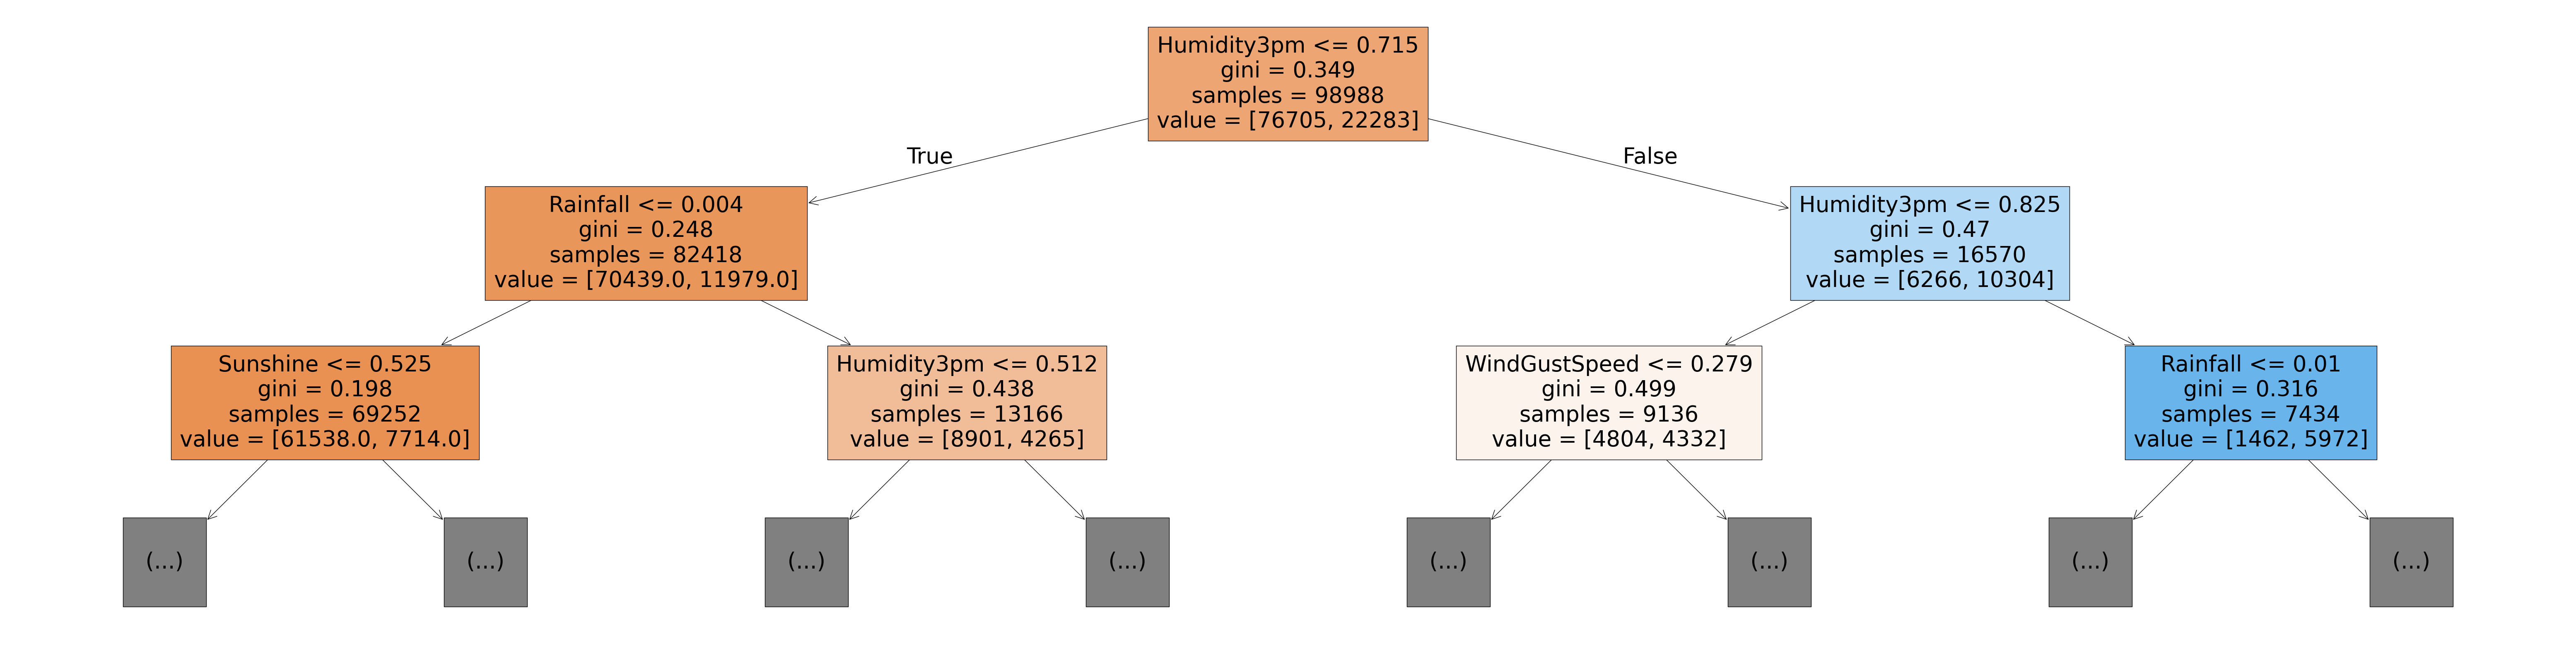

In [75]:
plt.figure(figsize=(80,20))
plot_tree(model, feature_names=X_train.columns, max_depth=2, filled=True);

In [76]:
# the full tree or export it as text
print(export_text(model, feature_names=list(X_train.columns)))

|--- Humidity3pm <= 0.72
|   |--- Rainfall <= 0.00
|   |   |--- Sunshine <= 0.52
|   |   |   |--- Pressure3pm <= 0.58
|   |   |   |   |--- WindGustSpeed <= 0.36
|   |   |   |   |   |--- Humidity3pm <= 0.28
|   |   |   |   |   |   |--- WindDir9am_NE <= 0.50
|   |   |   |   |   |   |   |--- Location_Watsonia <= 0.50
|   |   |   |   |   |   |   |   |--- Cloud9am <= 0.83
|   |   |   |   |   |   |   |   |   |--- WindSpeed3pm <= 0.07
|   |   |   |   |   |   |   |   |   |   |--- Pressure3pm <= 0.46
|   |   |   |   |   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |   |   |   |   |--- Pressure3pm >  0.46
|   |   |   |   |   |   |   |   |   |   |   |--- class: No
|   |   |   |   |   |   |   |   |   |--- WindSpeed3pm >  0.07
|   |   |   |   |   |   |   |   |   |   |--- MinTemp <= 0.32
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |   |--- MinTemp >  0.32
|   |   |   |   |   |   |   |   |   |   |   |--- truncated

[Text(0.5, 0.9285714285714286, 'Humidity3pm <= 0.715\ngini = 0.349\nsamples = 98988\nvalue = [76705, 22283]'),
 Text(0.25, 0.7857142857142857, 'Rainfall <= 0.004\ngini = 0.248\nsamples = 82418\nvalue = [70439.0, 11979.0]'),
 Text(0.375, 0.8571428571428572, 'True  '),
 Text(0.125, 0.6428571428571429, 'Sunshine <= 0.525\ngini = 0.198\nsamples = 69252\nvalue = [61538.0, 7714.0]'),
 Text(0.0625, 0.5, 'Pressure3pm <= 0.583\ngini = 0.363\nsamples = 12620\nvalue = [9618, 3002]'),
 Text(0.03125, 0.35714285714285715, 'WindGustSpeed <= 0.364\ngini = 0.469\nsamples = 4691\nvalue = [2932, 1759]'),
 Text(0.015625, 0.21428571428571427, 'Humidity3pm <= 0.275\ngini = 0.435\nsamples = 3251\nvalue = [2210, 1041]'),
 Text(0.0078125, 0.07142857142857142, '\n  (...)  \n'),
 Text(0.0234375, 0.07142857142857142, '\n  (...)  \n'),
 Text(0.046875, 0.21428571428571427, 'Humidity3pm <= 0.455\ngini = 0.5\nsamples = 1440\nvalue = [722, 718]'),
 Text(0.0390625, 0.07142857142857142, '\n  (...)  \n'),
 Text(0.0546875

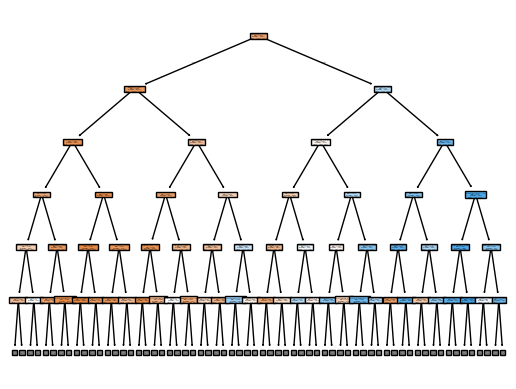

In [77]:
# visualizing deeper layers:
plot_tree(model, feature_names=X_train.columns, max_depth=5, filled=True)

How a Decision Tree is Created

Note the gini value in each box. This is the loss function used by the decision tree to decide which column should be used for splitting the data, and at what point the column should be split. A lower Gini index indicates a better split. A perfect split (only one class on each side) has a Gini index of 0

<img src="./data/images/CSC0gAo.png">

Conceptually speaking, while training the models evaluates all possible splits across all possible columns and picks the best one. Then, it recursively performs an optimal split for the two portions. In practice, however, it's very inefficient to check all possible splits, so the model uses a heuristic (predefined strategy) combined with some randomization.

The iterative approach of the machine learning workflow in the case of a decision tree involves growing the tree layer-by-layer:

<img src="./data/images/SupervisedLearning.png">

Checking the depth of the tree that was created.

In [78]:
model.tree_.max_depth

48

# Section 10 : tree_text

In [79]:
tree_text = export_text(model, max_depth=10, feature_names=list(X_train.columns))
print(tree_text[:5000])

|--- Humidity3pm <= 0.72
|   |--- Rainfall <= 0.00
|   |   |--- Sunshine <= 0.52
|   |   |   |--- Pressure3pm <= 0.58
|   |   |   |   |--- WindGustSpeed <= 0.36
|   |   |   |   |   |--- Humidity3pm <= 0.28
|   |   |   |   |   |   |--- WindDir9am_NE <= 0.50
|   |   |   |   |   |   |   |--- Location_Watsonia <= 0.50
|   |   |   |   |   |   |   |   |--- Cloud9am <= 0.83
|   |   |   |   |   |   |   |   |   |--- WindSpeed3pm <= 0.07
|   |   |   |   |   |   |   |   |   |   |--- Pressure3pm <= 0.46
|   |   |   |   |   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |   |   |   |   |--- Pressure3pm >  0.46
|   |   |   |   |   |   |   |   |   |   |   |--- class: No
|   |   |   |   |   |   |   |   |   |--- WindSpeed3pm >  0.07
|   |   |   |   |   |   |   |   |   |   |--- MinTemp <= 0.32
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |   |--- MinTemp >  0.32
|   |   |   |   |   |   |   |   |   |   |   |--- truncated

# Section 11 : Feature Importance

Based on the gini index computations, a decision tree assigns an "importance" value to each feature. These values can be used to interpret the results given by a decision tree.

In [80]:
model.feature_importances_

array([3.48942086e-02, 3.23605486e-02, 5.91385668e-02, 2.49619907e-02,
       4.94652143e-02, 5.63334673e-02, 2.80205998e-02, 2.98128801e-02,
       4.02182908e-02, 2.61441297e-01, 3.44145027e-02, 6.20573699e-02,
       1.36406176e-02, 1.69229866e-02, 3.50001550e-02, 3.04064076e-02,
       2.24086587e-03, 2.08018104e-03, 1.27475954e-03, 7.26936324e-04,
       1.39779517e-03, 1.15264873e-03, 6.92808159e-04, 1.80675598e-03,
       1.08370901e-03, 1.19773895e-03, 8.87119103e-04, 2.15764220e-03,
       1.67094731e-03, 7.98919493e-05, 1.10558668e-03, 1.42008656e-03,
       4.10087635e-04, 1.09028115e-03, 1.44164766e-03, 9.08284767e-04,
       1.05770304e-03, 6.18133455e-04, 1.80387272e-03, 2.10403527e-03,
       2.74413333e-04, 7.31599405e-04, 1.35408990e-03, 1.54759332e-03,
       1.30917564e-03, 1.07134670e-03, 8.36408023e-04, 1.62662229e-03,
       1.00326116e-03, 2.16053455e-03, 8.46802258e-04, 1.88919081e-03,
       9.29325203e-04, 1.29545157e-03, 1.27604831e-03, 5.12736888e-04,
      

Let's turn this into a dataframe and visualize the most important features.

In [81]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

In [82]:
importance_df.head(10)

,feature,importance
9,Humidity3pm,0.261441
11,Pressure3pm,0.062057
2,Rainfall,0.059139
5,WindGustSpeed,0.056333
4,Sunshine,0.049465
8,Humidity9am,0.040218
14,Temp9am,0.035000
0,MinTemp,0.034894
10,Pressure9am,0.034415
1,MaxTemp,0.032361


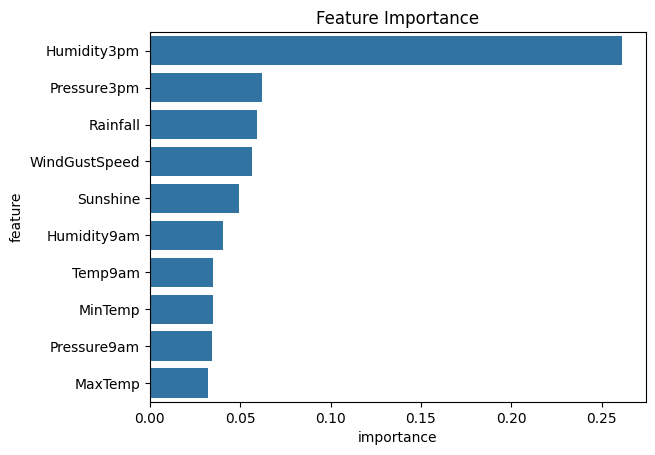

In [83]:
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature');

# Section 12 : Hyperparameter Tuning and Overfitting

As we saw in the previous section, our decision tree classifier memorized all training examples, leading to a 100% training accuracy, while the validation accuracy was only marginally better than a dumb baseline model. This phenomenon is called overfitting, and in this section, we'll look at some strategies for reducing overfitting.

The `DecisionTreeClassifier` accepts several arguments, some of which can be modified to reduce overfitting.

In [84]:
help(DecisionTreeClassifier)

Help on class DecisionTreeClassifier in module sklearn.tree._classes:

class DecisionTreeClassifier(sklearn.base.ClassifierMixin, BaseDecisionTree)
 |  DecisionTreeClassifier(*, criterion='gini', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, class_weight=None, ccp_alpha=0.0, monotonic_cst=None)
 |
 |  A decision tree classifier.
 |
 |  Read more in the :ref:`User Guide <tree>`.
 |
 |  Parameters
 |  ----------
 |  criterion : {"gini", "entropy", "log_loss"}, default="gini"
 |      The function to measure the quality of a split. Supported criteria are
 |      "gini" for the Gini impurity and "log_loss" and "entropy" both for the
 |      Shannon information gain, see :ref:`tree_mathematical_formulation`.
 |
 |  splitter : {"best", "random"}, default="best"
 |      The strategy used to choose the split at each node. Supported
 |      strategies ar

These arguments are called hyperparameters because they must be configured manually (as opposed to the parameters within the model which are _learned_ from the data). We'll explore a couple of hyperparameters:

- `max_depth`
- `max_leaf_nodes`

`max_depth`

By reducing the maximum depth of the decision tree, we can prevent the tree from memorizing all training examples, which may lead to better generalization

In [85]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)

In [86]:
model.fit(X_train, train_targets)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


We can compute the accuracy of the model on the training and validation sets using `model.score`

In [87]:
model.score(X_train, train_targets)

0.8291308037337859

In [88]:
model.score(X_val, val_targets)

0.8334397307178921

Great, while the training accuracy of the model has gone down, the validation accuracy of the model has increased significantly.

In [89]:
model.classes_

array(['No', 'Yes'], dtype=object)

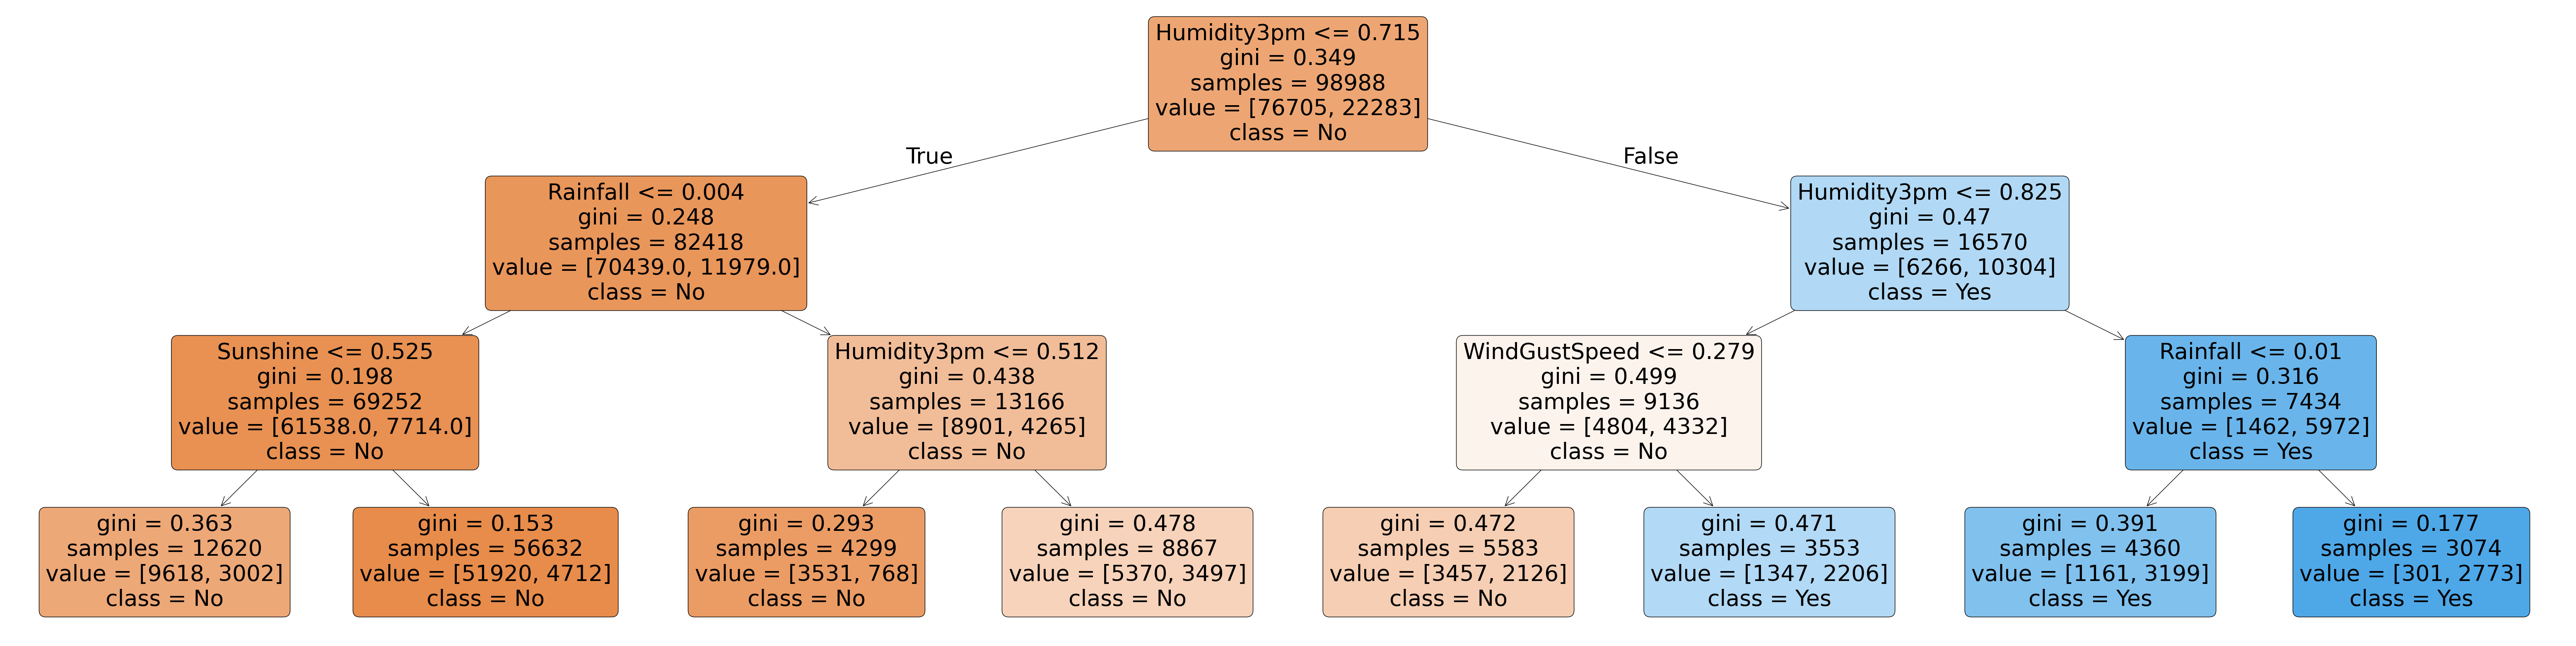

In [90]:
plt.figure(figsize=(80,20))
plot_tree(model, feature_names=X_train.columns, filled=True, rounded=True, class_names=model.classes_);

In [91]:
print(export_text(model, feature_names=list(X_train.columns)))

|--- Humidity3pm <= 0.72
|   |--- Rainfall <= 0.00
|   |   |--- Sunshine <= 0.52
|   |   |   |--- class: No
|   |   |--- Sunshine >  0.52
|   |   |   |--- class: No
|   |--- Rainfall >  0.00
|   |   |--- Humidity3pm <= 0.51
|   |   |   |--- class: No
|   |   |--- Humidity3pm >  0.51
|   |   |   |--- class: No
|--- Humidity3pm >  0.72
|   |--- Humidity3pm <= 0.82
|   |   |--- WindGustSpeed <= 0.28
|   |   |   |--- class: No
|   |   |--- WindGustSpeed >  0.28
|   |   |   |--- class: Yes
|   |--- Humidity3pm >  0.82
|   |   |--- Rainfall <= 0.01
|   |   |   |--- class: Yes
|   |   |--- Rainfall >  0.01
|   |   |   |--- class: Yes



Let's experiment with different depths using a helper function.

In [92]:
def max_depth_error(md):
    model = DecisionTreeClassifier(max_depth=md, random_state=42)
    model.fit(X_train, train_targets)
    train_acc = 1 - model.score(X_train, train_targets)
    val_acc = 1 - model.score(X_val, val_targets)
    return {'Max Depth': md, 'Training Error': train_acc, 'Validation Error': val_acc}

In [93]:
%%time
errors_df = pd.DataFrame([max_depth_error(md) for md in range(1, 21)])

CPU times: total: 21.4 s
Wall time: 21.6 s


In [94]:
errors_df # type: ignore

,Max Depth,Training Error,Validation Error
0,1,0.184315,0.177935
1,2,0.179547,0.172712
2,3,0.170869,0.166560
3,4,0.165707,0.164355
4,5,0.160676,0.159074
5,6,0.156271,0.157275
6,7,0.153312,0.154605
7,8,0.147806,0.158029
8,9,0.140906,0.156578
9,10,0.132945,0.157333


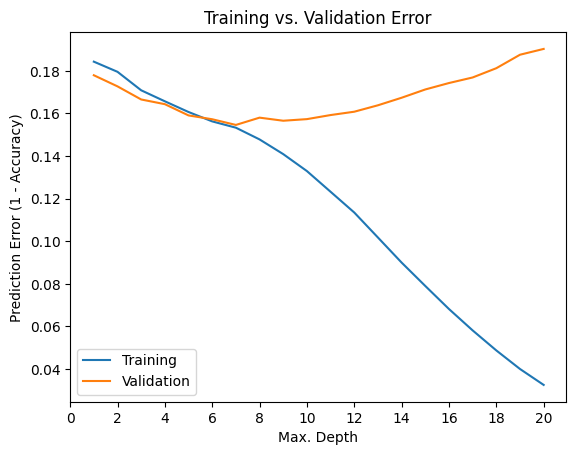

In [95]:
plt.figure()
plt.plot(errors_df['Max Depth'], errors_df['Training Error']) # type: ignore
plt.plot(errors_df['Max Depth'], errors_df['Validation Error']) # type: ignore
plt.title('Training vs. Validation Error')
plt.xticks(range(0,21, 2))
plt.xlabel('Max. Depth')
plt.ylabel('Prediction Error (1 - Accuracy)')
plt.legend(['Training', 'Validation'])

This is a common pattern you'll see with all machine learning algorithms:

<img src="./data/images/EJCrSZw.png" width="480">

You'll often need to tune hyperparameters carefully to find the optimal fit. In the above case, it appears that a maximum depth of 7 results in the lowest validation error.

In [96]:
model = DecisionTreeClassifier(max_depth=7, random_state=42).fit(X_train, train_targets)
model.score(X_val, val_targets)

0.8453949277465034

`max_leaf_nodes`

Another way to control the size of complexity of a decision tree is to limit the number of leaf nodes. This allows branches of the tree to have varying depths. 

In [97]:
model = DecisionTreeClassifier(max_leaf_nodes=128, random_state=42)

In [98]:
model.fit(X_train, train_targets)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,128
,min_impurity_decrease,0.0
,class_weight,None


In [99]:
model.score(X_train, train_targets)

0.8480421869317493

In [100]:
model.tree_.max_depth

12

Notice that the model was able to achieve a greater depth of 12 for certain paths while keeping other paths shorter.

In [101]:
model_text = export_text(model, feature_names=list(X_train.columns))
print(model_text[:3000])

|--- Humidity3pm <= 0.72
|   |--- Rainfall <= 0.00
|   |   |--- Sunshine <= 0.52
|   |   |   |--- Pressure3pm <= 0.58
|   |   |   |   |--- WindGustSpeed <= 0.36
|   |   |   |   |   |--- Humidity3pm <= 0.28
|   |   |   |   |   |   |--- class: No
|   |   |   |   |   |--- Humidity3pm >  0.28
|   |   |   |   |   |   |--- Sunshine <= 0.05
|   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |--- Sunshine >  0.05
|   |   |   |   |   |   |   |--- Pressure3pm <= 0.43
|   |   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |   |--- Pressure3pm >  0.43
|   |   |   |   |   |   |   |   |--- Humidity3pm <= 0.57
|   |   |   |   |   |   |   |   |   |--- WindDir9am_NE <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- WindDir9am_NNE <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: No
|   |   |   |   |   |   |   |   |   |   |--- WindDir9am_NNE >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: No
|   |   |   |   |   |   |   |   |   |--- WindD

# Section 13 : Training a Random Forest

While tuning the hyperparameters of a single decision tree may lead to some improvements, a much more effective strategy is to combine the results of several decision trees trained with slightly different parameters. This is called a random forest. 

The key idea here is that each decision tree in the forest will make different kinds of errors, and upon averaging, many of their errors will cancel out. This idea is also known as the "wisdom of the crowd" in common parlance:

<img src="./data/images/4Dg0XK4.png" width="480">

A random forest works by averaging/combining the results of several decision trees:

<img src="./data/images/Random Forest 03.gif" width="640">

We'll use the `RandomForestClassifier` class from `sklearn.ensemble`.

In [102]:
from sklearn.ensemble import RandomForestClassifier

# Section 13 : model

In [103]:
model = RandomForestClassifier(n_jobs=-1, random_state=42)

Great choice, Hiral! That line:

```python
model = RandomForestClassifier(n_jobs=-1, random_state=42)
```

is creating a **Random Forest Classifier** using scikit-learn. Let’s break it down in detail:

---

🌳 `RandomForestClassifier`

This is an **ensemble learning method** that builds multiple decision trees and combines their predictions. It’s powerful because:

- Each tree is trained on a random subset of the data and features (bootstrapping + feature bagging)
- Final prediction is made by **majority vote** (for classification) or **average** (for regression)
- It reduces overfitting and improves generalization compared to a single decision tree

---

⚙️ `n_jobs=-1`

This controls **parallel processing**:

- `n_jobs=-1` tells scikit-learn to use **all available CPU cores**
- This speeds up training and prediction, especially when you have many trees or a large dataset

If you set `n_jobs=1`, it runs on a single core. If you set `n_jobs=4`, it uses 4 cores. `-1` is the smart default for full speed.

---

🎲 `random_state=42`

This sets the **random seed** for reproducibility:

- Random forests involve randomness in bootstrapping and feature selection
- Setting `random_state=42` ensures that every time you run the code, you get the **same model structure and results**
- `42` is a popular seed value (a geeky nod to *The Hitchhiker’s Guide to the Galaxy*)

---

🧠 Summary

This line creates a model that is:

- Fast (uses all cores)
- Stable (reproducible results)
- Robust (ensemble of trees)


In [104]:
%%time
model.fit(X_train, train_targets)

CPU times: total: 33.7 s
Wall time: 2.08 s


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [105]:
model.score(X_train, train_targets)

0.9999494888269285

In [106]:
model.score(X_val, val_targets)

0.8566537055307295

Once again, the training accuracy is 100%, but this time the validation accuracy is much better. In fact, it is better than the best single decision tree we had trained so far.

This general technique of combining the results of many models is called "ensembling", it works because most errors of individual models cancel out on averaging. Here's what it looks like visually:

<img src="./data/images/qJo8D8b.png" width="480">


We can also look at the probabilities for the predictions. The probability of a class is simply the fraction of trees which that predicted the given class.

In [107]:
train_probs = model.predict_proba(X_train)
train_probs

array([[0.93, 0.07],
       [1.  , 0.  ],
       [0.99, 0.01],
       ...,
       [0.99, 0.01],
       [1.  , 0.  ],
       [0.96, 0.04]], shape=(98988, 2))

We can can access individual decision trees using `model.estimators_`

In [108]:
model.estimators_[0]

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,random_state,1608637542
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [109]:
len(model.estimators_)

100

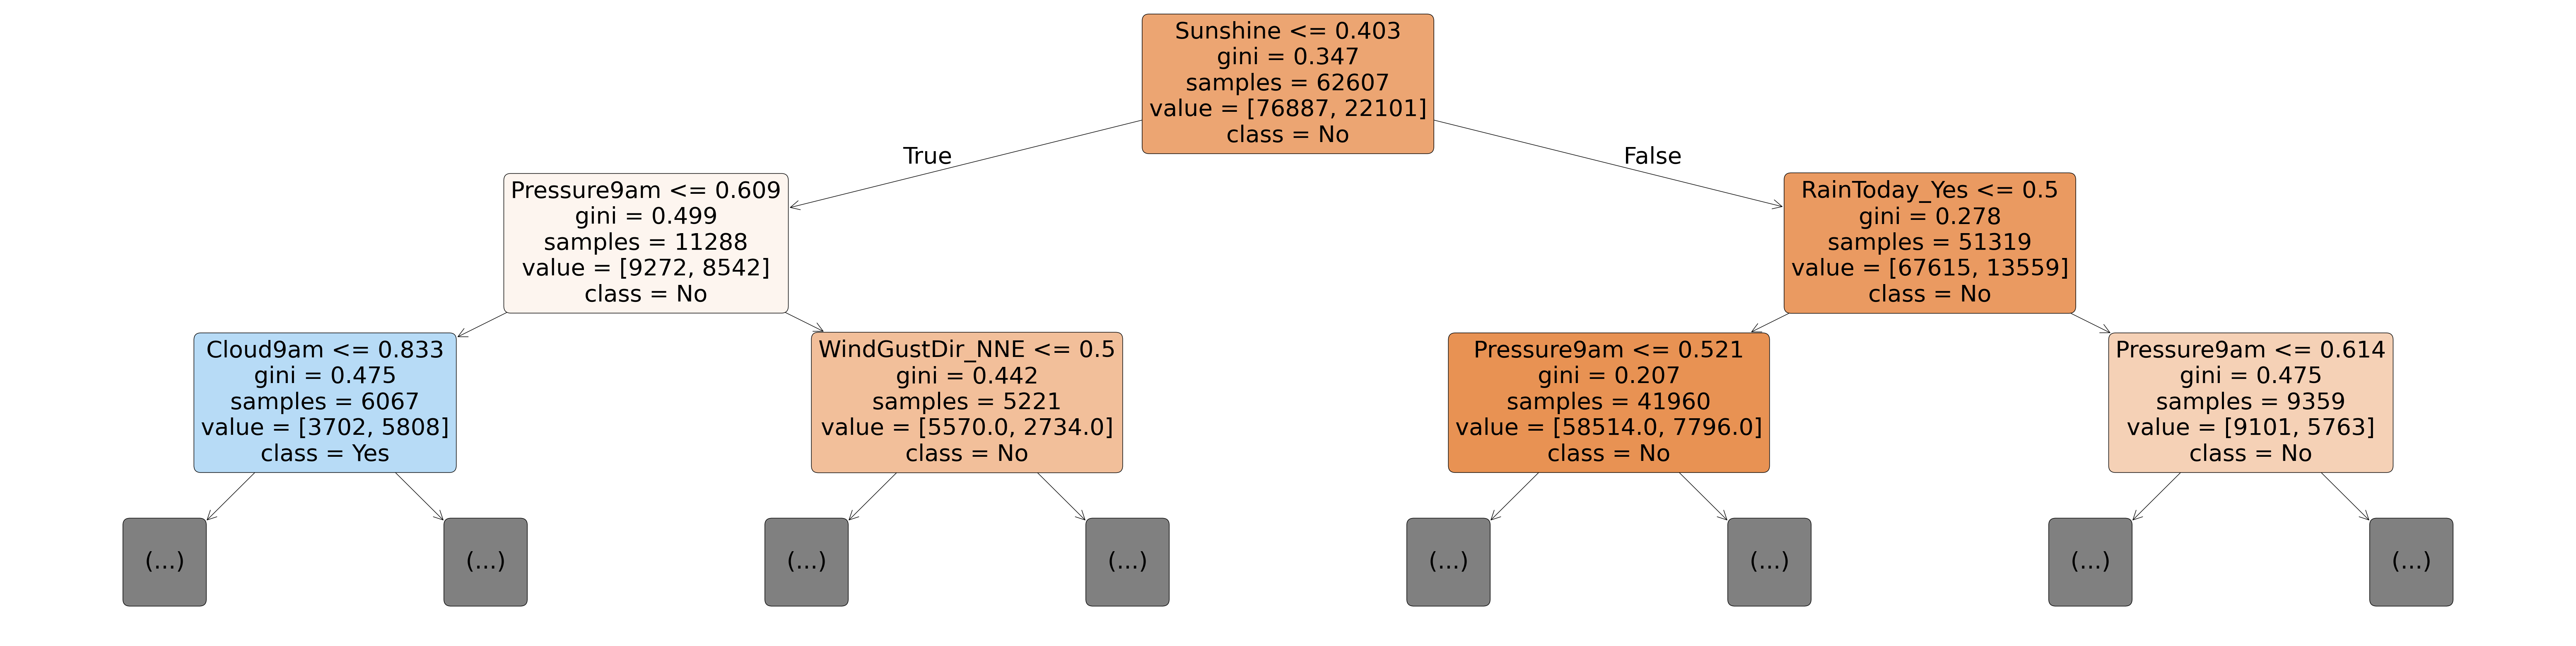

In [110]:
plt.figure(figsize=(80,20))
plot_tree(model.estimators_[0], max_depth=2, feature_names=X_train.columns, filled=True, rounded=True, class_names=model.classes_);

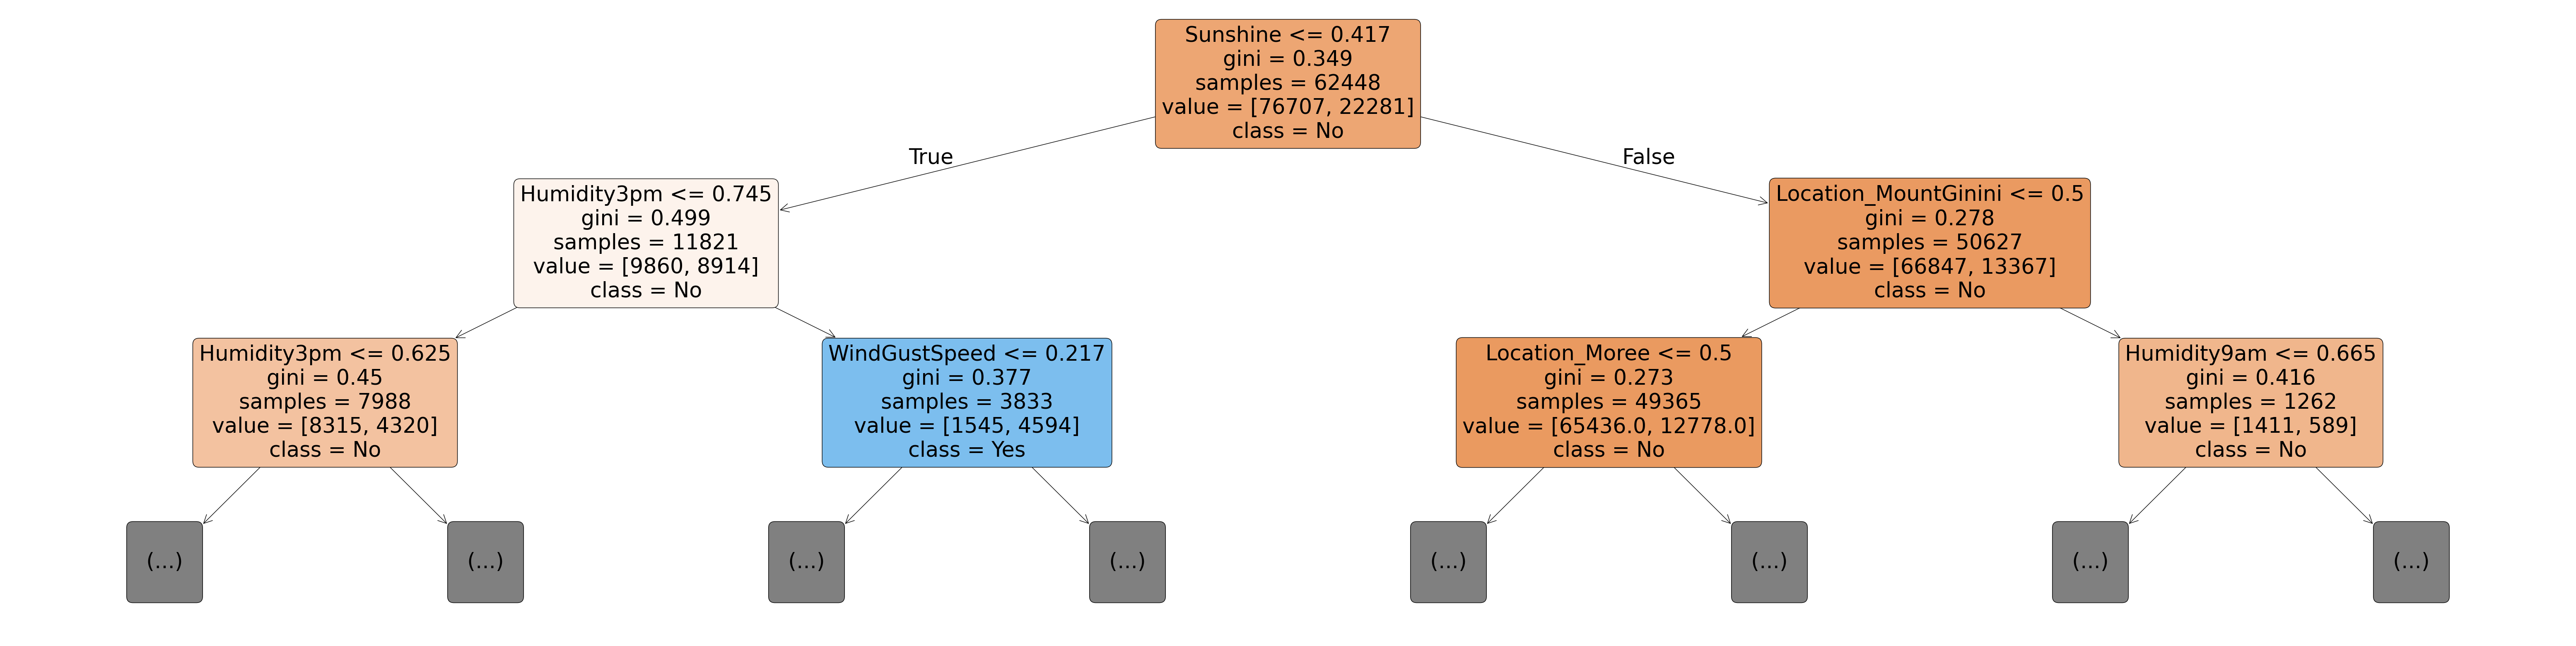

In [111]:
plt.figure(figsize=(80,20))
plot_tree(model.estimators_[15], max_depth=2, feature_names=X_train.columns, filled=True, rounded=True, class_names=model.classes_);

Just like decision tree, random forests also assign an "importance" to each feature, by combining the importance values from individual trees.

In [112]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

In [113]:
importance_df.head(10)

,feature,importance
9,Humidity3pm,0.139904
4,Sunshine,0.053696
11,Pressure3pm,0.052713
8,Humidity9am,0.050051
2,Rainfall,0.048077
10,Pressure9am,0.047944
5,WindGustSpeed,0.047477
15,Temp3pm,0.044379
1,MaxTemp,0.041865
0,MinTemp,0.041199


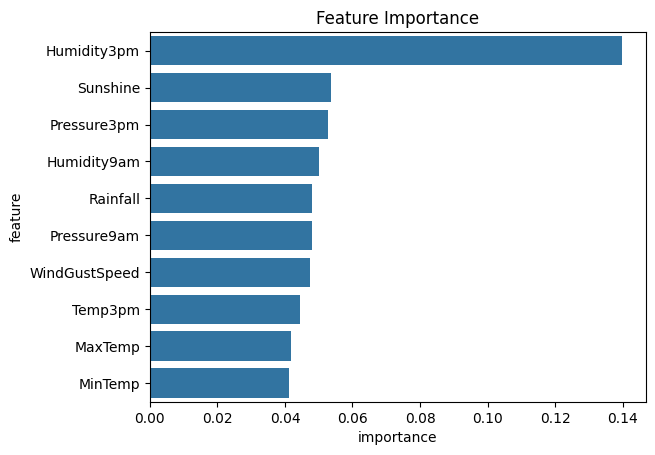

In [114]:
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature');

# Section 14 : Hyperparameter Tuning with Random Forests

Just like decision trees, random forests also have several hyperparameters. In fact many of these hyperparameters are applied to the underlying decision trees.

Let's create a base model with which we can compare models with tuned hyperparameters.

In [115]:
base_model = RandomForestClassifier(random_state=42, n_jobs=-1).fit(X_train, train_targets)

In [116]:
base_train_acc = base_model.score(X_train, train_targets)
base_val_acc = base_model.score(X_val, val_targets)

In [117]:
base_accs = base_train_acc, base_val_acc
base_accs

(0.9999494888269285, 0.8566537055307295)

`n_estimators`

This controls the number of decision trees in the random forest. The default value is 100. For larger datasets, it helps to have a greater number of estimators. As a general rule, try to have as few estimators as needed. 

10 estimators

In [118]:
model = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=10)

In [119]:
model.fit(X_train, train_targets)

,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [120]:
model.score(X_train, train_targets), model.score(X_val, val_targets)

(0.986958015112943, 0.8485868492832686)

In [121]:
base_accs

(0.9999494888269285, 0.8566537055307295)

500 estimators

In [122]:
model = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=500)
model.fit(X_train, train_targets)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [123]:
model.score(X_train, train_targets)

0.9999797955307714

In [124]:
model.score(X_val, val_targets)

0.8577563693343393

In [125]:
base_accs

(0.9999494888269285, 0.8566537055307295)

1000 estimators

In [126]:
model = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=1000)
model.fit(X_train, train_targets)

,n_estimators,1000
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [127]:
model.score(X_train, train_targets)

0.9999797955307714

In [128]:
model.score(X_val, val_targets)

0.85694388021589

In [129]:
base_accs

(0.9999494888269285, 0.8566537055307295)

# Section 15 : Manual search with a loop

In [130]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

estimator_range = [50, 100, 200, 300, 400, 500, 600, 800, 1000]
train_accs = []
val_accs = []

for n in estimator_range:
    model = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    model.fit(X_train, train_targets)
    
    train_accs.append(model.score(X_train, train_targets))
    val_accs.append(model.score(X_val, val_targets))

# Visualize
import matplotlib.pyplot as plt

plt.plot(estimator_range, train_accs, label='Train Accuracy')
plt.plot(estimator_range, val_accs, label='Validation Accuracy')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.title('Random Forest Performance vs. Number of Trees')
plt.legend()
plt.grid(True)
plt.show()

KeyboardInterrupt: 

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Range of n_estimators to test
estimator_range = [50, 100, 200, 300, 400, 500, 600, 800, 1000]

train_scores = []
val_scores = []

for n in estimator_range:
    model = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    model.fit(X_train, train_targets)
    
    train_acc = model.score(X_train, train_targets)
    val_acc = model.score(X_val, val_targets)
    
    train_scores.append(train_acc)
    val_scores.append(val_acc)
    print(f"n_estimators={n} → Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

# Find best n_estimators based on validation accuracy
best_index = val_scores.index(max(val_scores))
best_n = estimator_range[best_index]
best_val_acc = val_scores[best_index]

print(f"\n Best n_estimators: {best_n} with Validation Accuracy: {best_val_acc:.4f}")

n_estimators=50 → Train Acc: 0.9996, Val Acc: 0.8561
n_estimators=100 → Train Acc: 0.9999, Val Acc: 0.8567
n_estimators=200 → Train Acc: 1.0000, Val Acc: 0.8562
n_estimators=300 → Train Acc: 1.0000, Val Acc: 0.8574
n_estimators=400 → Train Acc: 1.0000, Val Acc: 0.8577
n_estimators=500 → Train Acc: 1.0000, Val Acc: 0.8578
n_estimators=600 → Train Acc: 1.0000, Val Acc: 0.8579
n_estimators=800 → Train Acc: 1.0000, Val Acc: 0.8575
n_estimators=1000 → Train Acc: 1.0000, Val Acc: 0.8569

 Best n_estimators: 600 with Validation Accuracy: 0.8579


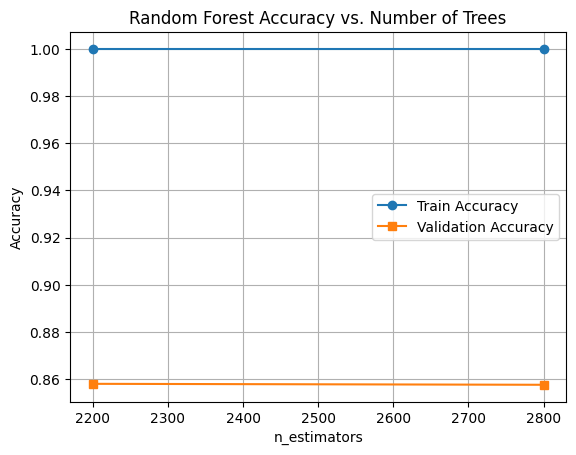

In [ ]:
plt.plot(estimator_range, train_scores, label='Train Accuracy', marker='o')
plt.plot(estimator_range, val_scores, label='Validation Accuracy', marker='s')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy vs. Number of Trees')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Range of n_estimators to test
estimator_range = [600, 800, 1000, 1200, 1400, 1600, 1800, 2000, 2200]

train_scores = []
val_scores = []

for n in estimator_range:
    model = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    model.fit(X_train, train_targets)
    
    train_acc = model.score(X_train, train_targets)
    val_acc = model.score(X_val, val_targets)
    
    train_scores.append(train_acc)
    val_scores.append(val_acc)
    print(f"n_estimators={n} → Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

# Find best n_estimators based on validation accuracy
best_index = val_scores.index(max(val_scores))
best_n = estimator_range[best_index]
best_val_acc = val_scores[best_index]

print(f"\n✅ Best n_estimators: {best_n} with Validation Accuracy: {best_val_acc:.4f}")

n_estimators=600 → Train Acc: 1.0000, Val Acc: 0.8579
n_estimators=800 → Train Acc: 1.0000, Val Acc: 0.8575
n_estimators=1000 → Train Acc: 1.0000, Val Acc: 0.8569
n_estimators=1200 → Train Acc: 1.0000, Val Acc: 0.8568
n_estimators=1400 → Train Acc: 1.0000, Val Acc: 0.8573
n_estimators=1600 → Train Acc: 1.0000, Val Acc: 0.8574
n_estimators=1800 → Train Acc: 1.0000, Val Acc: 0.8578
n_estimators=2000 → Train Acc: 1.0000, Val Acc: 0.8576
n_estimators=2200 → Train Acc: 1.0000, Val Acc: 0.8580

✅ Best n_estimators: 2200 with Validation Accuracy: 0.8580


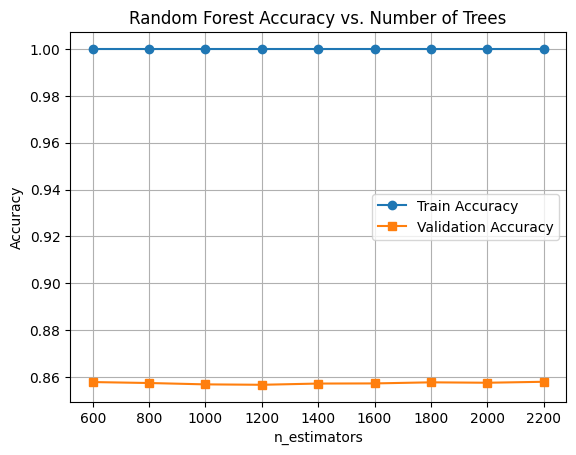

In [ ]:
plt.plot(estimator_range, train_scores, label='Train Accuracy', marker='o')
plt.plot(estimator_range, val_scores, label='Validation Accuracy', marker='s')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy vs. Number of Trees')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Range of n_estimators to test
estimator_range = [600, 2200, 2400]

train_scores = []
val_scores = []

for n in estimator_range:
    model = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    model.fit(X_train, train_targets)
    
    train_acc = model.score(X_train, train_targets)
    val_acc = model.score(X_val, val_targets)
    
    train_scores.append(train_acc)
    val_scores.append(val_acc)
    print(f"n_estimators={n} → Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

# Find best n_estimators based on validation accuracy
best_index = val_scores.index(max(val_scores))
best_n = estimator_range[best_index]
best_val_acc = val_scores[best_index]

print(f"\n✅ Best n_estimators: {best_n} with Validation Accuracy: {best_val_acc:.4f}")

n_estimators=600 → Train Acc: 1.0000, Val Acc: 0.8579
n_estimators=2200 → Train Acc: 1.0000, Val Acc: 0.8580
n_estimators=2400 → Train Acc: 1.0000, Val Acc: 0.8579

✅ Best n_estimators: 2200 with Validation Accuracy: 0.8580


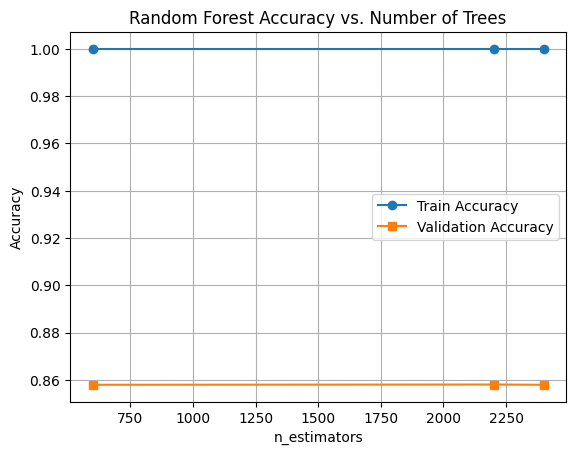

In [ ]:
plt.plot(estimator_range, train_scores, label='Train Accuracy', marker='o')
plt.plot(estimator_range, val_scores, label='Validation Accuracy', marker='s')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy vs. Number of Trees')
plt.legend()
plt.grid(True)
plt.show()

In [131]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Range of n_estimators to test
estimator_range = [2200, 2800]

train_scores = []
val_scores = []

for n in estimator_range:
    model = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    model.fit(X_train, train_targets)
    
    train_acc = model.score(X_train, train_targets)
    val_acc = model.score(X_val, val_targets)
    
    train_scores.append(train_acc)
    val_scores.append(val_acc)
    print(f"n_estimators={n} → Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

# Find best n_estimators based on validation accuracy
best_index = val_scores.index(max(val_scores))
best_n = estimator_range[best_index]
best_val_acc = val_scores[best_index]

print(f"\n✅ Best n_estimators: {best_n} with Validation Accuracy: {best_val_acc:.4f}")

KeyboardInterrupt: 

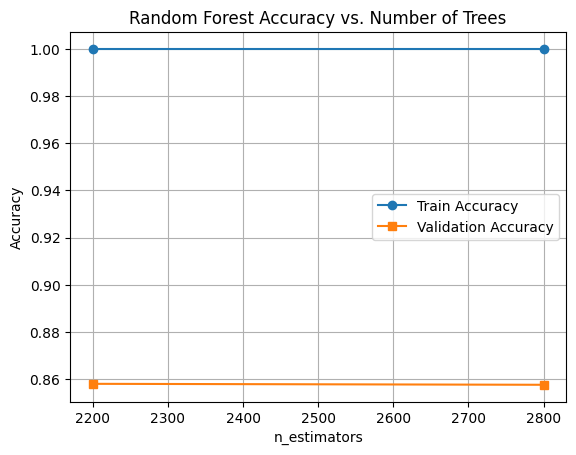

In [ ]:
plt.plot(estimator_range, train_scores, label='Train Accuracy', marker='o')
plt.plot(estimator_range, val_scores, label='Validation Accuracy', marker='s')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy vs. Number of Trees')
plt.legend()
plt.grid(True)
plt.show()

# Section 15 : `max_features`

Instead of picking all features for every split, we can specify only a fraction of features to be chosen randomly.

<img src="./data/images/FXGWMDY.png" width="720">

Notice that the default value `auto` causes only $\sqrt{n}$ out of total features ( $n$ ) to be chosen randomly at each split. This is the reason each decision tree is in the forest is different. While it may seem counterintuitive, choosing all features for every split of every tree will lead to identical trees, so the random forest will not generalize well. 

In [ ]:
model = RandomForestClassifier(max_features='log2', random_state=42, n_jobs=-1)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

settings = ['sqrt', 'log2', None, 5, 10]
results = []

for setting in settings:
    model = RandomForestClassifier(max_features=setting, random_state=42, n_jobs=-1)
    model.fit(X_train, train_targets)
    acc = model.score(X_val, val_targets)
    results.append((setting, acc))
    print(f"max_features={setting} → Validation Accuracy: {acc:.4f}")

max_features=sqrt → Validation Accuracy: 0.8567
max_features=log2 → Validation Accuracy: 0.8559
max_features=None → Validation Accuracy: 0.8557
max_features=5 → Validation Accuracy: 0.8554
max_features=10 → Validation Accuracy: 0.8567


In [ ]:
import pandas as pd
import plotly.express as px

df = pd.DataFrame(results, columns=['max_features', 'Validation Accuracy'])
fig = px.bar(df, x='max_features', y='Validation Accuracy', title='Effect of max_features on Validation Accuracy')
fig.show()

In [ ]:
base_accs

(0.9999494888269285, 0.8566537055307295)

# Section 16 : `max_depth` and `max_leaf_nodes`

These arguments are passed directly to each decision tree, and control the maximum depth and max. no leaf nodes of each tree respectively. By default, no maximum depth is specified, which is why each tree has a training accuracy of 100%. You can specify a `max_depth` to reduce overfitting.

<img src="./data/images/EJCrSZw.png" width="480">

Let's define a helper function to `max depth`, `max_leaf_nodes` and other hyperparameters easily.

In [132]:
from sklearn.ensemble import RandomForestClassifier
def test_params(**params):
    model = RandomForestClassifier(random_state=42, n_jobs=-1, **params).fit(X_train, train_targets)
    return model.score(X_train, train_targets), model.score(X_val, val_targets)

Let's test a few values of `max_depth`.

In [133]:
test_params(max_depth=5)

(0.8197862367155615, 0.8240961058557251)

In [134]:
test_params(max_depth=25)

(0.9775730391562614, 0.8558992513493123)

In [135]:
test_params(max_leaf_nodes=2**5)

(0.8314341132258456, 0.833904010214149)

In [136]:
test_params(max_leaf_nodes=2**20)

(0.9999595910615429, 0.8568278103418258)

In [137]:
base_accs # no max depth or max leaf nodes

(0.9999494888269285, 0.8566537055307295)

# Section 17 : `min_samples_split` and `min_samples_leaf`

By default, the decision tree classifier tries to split every node that has 2 or more. You can increase the values of these arguments to change this behavior and reduce overfitting, especially for very large datasets.

🌱 `min_samples_split`

- **Definition**: Minimum number of samples required to split an internal node.
- **Default**: `2`
- **Effect**:
  - If set to a higher value (e.g., `10`, `20`), the tree becomes **less greedy** and avoids splitting on small noisy subsets.
  - This helps prevent overfitting by enforcing **minimum group size** before a split is allowed.

Example:
```python
RandomForestClassifier(min_samples_split=10)
```
This means a node must have **at least 10 samples** to be split.

---

🍃 `min_samples_leaf`

- **Definition**: Minimum number of samples required to be at a leaf node.
- **Default**: `1`
- **Effect**:
  - If set to a higher value (e.g., `5`, `10`), each leaf must represent a **larger group of samples**.
  - This smooths predictions and avoids leaves that represent tiny, possibly noisy subsets.

🧠 When to Tune These

- If your model is **overfitting** (high train accuracy, low validation accuracy), increase these values.
- If your dataset is **very large**, tuning these helps reduce training time and memory usage.
- If your target classes are **imbalanced**, setting `min_samples_leaf` helps avoid tiny leaves for minority classes.


In [138]:
test_params(min_samples_split=3, min_samples_leaf=2)

(0.9625005051117307, 0.8565956705936975)

In [139]:
test_params(min_samples_split=100, min_samples_leaf=60)

(0.8495676243585081, 0.8451047530613429)

In [140]:
base_accs

(0.9999494888269285, 0.8566537055307295)

# Section 18 : `min_impurity_decrease`

This argument is used to control the threshold for splitting nodes. A node will be split if this split induces a decrease of the impurity (Gini index) greater than or equal to this value. It's default value is 0, and you can increase it to reduce overfitting.


In [141]:
test_params(min_impurity_decrease=1e-6)

(0.9888168262819735, 0.8561313910974406)

In [142]:
test_params(min_impurity_decrease=1e-2)

(0.774891906089627, 0.7882885497069235)

# Section 19 : `bootstrap`, `max_samples` 

By default, a random forest doesn't use the entire dataset for training each decision tree. Instead it applies a technique called bootstrapping. For each tree, rows from the dataset are picked one by one randomly, with replacement i.e. some rows may not show up at all, while some rows may show up multiple times.


<img src="./data/images/W8UGaEA.png" width="640">

Bootstrapping helps the random forest generalize better, because each decision tree only sees a fraction of th training set, and some rows randomly get higher weightage than others.

In [143]:
test_params(bootstrap=False)

(0.9999797955307714, 0.8567697754047937)

In [144]:
base_accs

(0.9999494888269285, 0.8566537055307295)

When bootstrapping is enabled, you can also control the number or fraction of rows to be considered for each bootstrap using `max_samples`. This can further generalize the model.

<img src="./data/images/rsdrL1W.png" width="640">

In [145]:
test_params(max_samples=0.9)

(0.9997676486038711, 0.8565376356566653)

In [146]:
base_accs

(0.9999494888269285, 0.8566537055307295)

# Section 20 : `class_weight`

In [147]:
model.classes_

[array(['No', 'Yes'], dtype=object)]

In [148]:
test_params(class_weight='balanced')

(0.9999595910615429, 0.8553769369160235)

In [149]:
test_params(class_weight={'No': 1, 'Yes': 2})

(0.9999595910615429, 0.8558412164122802)

In [150]:
base_accs

(0.9999494888269285, 0.8566537055307295)

# Section 21 : Putting it together

Let's train a random forest with customized hyperparameters based on our learnings. Of course, different hyperpraams

In [151]:
model = RandomForestClassifier(n_jobs=-1, 
                               random_state=42, 
                               n_estimators=500,
                               max_features=7,
                               max_depth=30, 
                               class_weight={'No': 1, 'Yes': 1.5})

In [152]:
model.fit(X_train, train_targets)

,n_estimators,500
,criterion,'gini'
,max_depth,30
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,7
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [153]:
model.score(X_train, train_targets), model.score(X_val, val_targets)

(0.9920192346547057, 0.8563054959085369)

In [154]:
base_accs

(0.9999494888269285, 0.8566537055307295)

In [155]:
raw_df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,2017-06-20,Uluru,3.5,21.8,0.0,NaN,NaN,E,31.0,ESE,...,59.0,27.0,1024.7,1021.2,NaN,NaN,9.4,20.9,No,No
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No


# Section 21 : Making Predictions on New Inputs

In [156]:
def predict_input(single_input):
    input_df = pd.DataFrame([single_input])
    input_df[numeric_cols] = imputer.transform(input_df[numeric_cols])
    input_df[numeric_cols] = scaler.transform(input_df[numeric_cols])
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    X_input = input_df[numeric_cols + encoded_cols]
    pred = model.predict(X_input)[0]
    prob = model.predict_proba(X_input)[0][list(model.classes_).index(pred)]
    return pred, prob

# Summary and References


Important terms:

* Decision tree
* Overfitting
* Hyperparameter
* Regularization
* Random forest
* Ensembling